# Day 7: Model Diagnostics

**Goal:** Find where the model fails systematically. Use this analysis to:
1. Update the README's 'Limitations' section with concrete, evidence-backed findings
2. Be ready to answer 'where does your model break?' in interviews
3. Decide if any failure mode is fixable in scope vs. should be documented

**Approach:** Each section asks a specific question, runs the analysis, and ends with an explicit takeaway you can quote later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_parquet('../data/processed/predictions.parquet')
print(f'Loaded {len(df):,} scored properties')
df.head(2)

Loaded 60,777 scored properties


,PROP_ID,LOC_ID,BLDG_VAL,LAND_VAL,OTHER_VAL,TOTAL_VAL,FY,LOT_SIZE,LS_DATE,LS_PRICE,USE_CODE,SITE_ADDR,ADDR_NUM,FULL_STR,LOCATION,CITY,ZIP,OWNER1,OWN_ADDR,OWN_CITY,OWN_STATE,OWN_ZIP,OWN_CO,LS_BOOK,LS_PAGE,REG_ID,ZONING,YEAR_BUILT,BLD_AREA,UNITS,RES_AREA,STYLE,STORIES,NUM_ROOMS,LOT_UNITS,CAMA_ID,TOWN_ID,USE_DESC,CITY_NAME,FY_YEAR,USE_CODE_NUM,LS_YEAR,LONGITUDE,LATITUDE,DIST_TO_T_KM,NEAREST_T_STATION,PRICE_PER_SQFT,NBR_MEDIAN_PSF,NBR_SAMPLE_SIZE,PREDICTED_PRICE,RESIDUAL,RESIDUAL_PCT,LOG_RESIDUAL_Z,ANOMALY_FLAG,PRICE_RATIO
0,0100174000,F_783599_2964200,958000,221600,0,1179600,2023,0.0,20150615,665000,105,309 Lexington ST,309,Lexington ST,,EAST BOSTON,02128,SMITH THOMAS L,309 LEXINGTON ST,EAST BOSTON,MA,02128,US,54607,290,,,1900,0,0,2925,Decker,3.0,14,A,1000004,35,Three-Family Residential,Boston,2023,105.0,2015.0,-71.028349,42.380949,0.473752,Wood Island,227.350427,NaN,0,528978.781465,136021.218535,25.713927,1.005737,normal,1.257139
1,2008430000,F_746124_2929194,411800,202600,0,614400,2023,0.0,20151230,372000,101,186 PERHAM ST,186,PERHAM ST,,WEST ROXBURY,02132,NOONAN JOHN D JR,186 PERHAM ST,WEST ROXBURY,MA,02132,,55538,198,,,1920,0,0,1384,Colonial,2.0,6,A,1114688,35,Single Family Residential,Boston,2023,101.0,2015.0,-71.167551,42.285376,4.609785,Chestnut Hill,268.786127,NaN,0,460012.576900,-88012.576900,-19.132646,-0.953069,normal,0.808674


---
## 1. The big picture: predicted vs actual

**Question:** Does the scatter of predictions vs reality look reasonable?

**Look for:** Tight cloud along the y=x diagonal = good. Visible bias (cloud sits below the line for high prices = systematic underprediction of expensive homes). Heteroscedastic spread (wider error at higher prices) is normal.

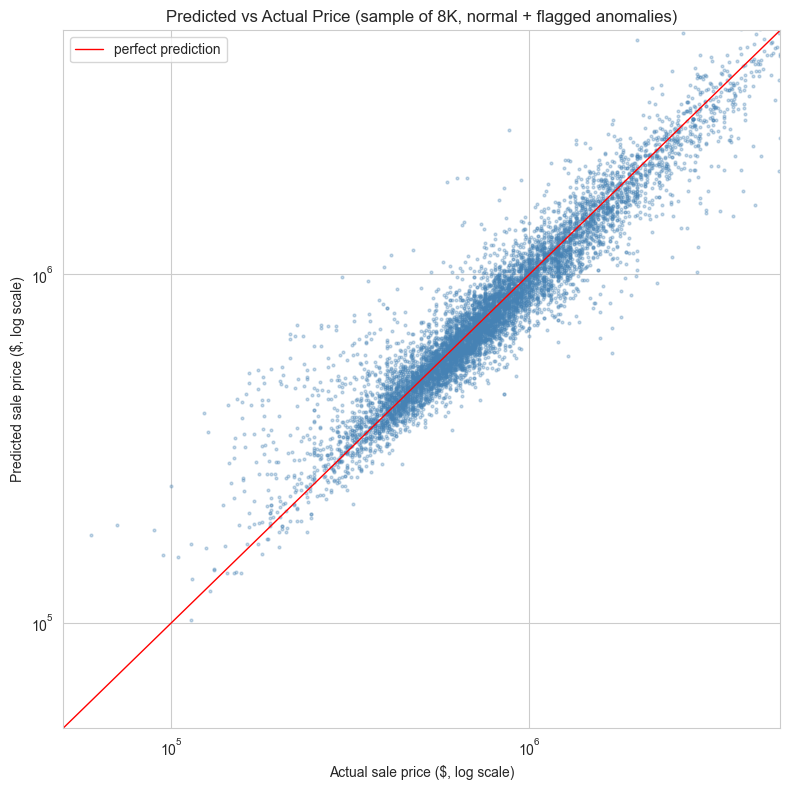

In [2]:
# Sample to keep plot fast
sample = df.sample(min(8000, len(df)), random_state=42)
sample = sample[sample['ANOMALY_FLAG'].isin(['normal', 'overpriced', 'underpriced'])]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sample['LS_PRICE'], sample['PREDICTED_PRICE'], s=4, alpha=0.3, color='steelblue')
lims = [50_000, 5_000_000]
ax.plot(lims, lims, 'r-', linewidth=1, label='perfect prediction')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual sale price ($, log scale)')
ax.set_ylabel('Predicted sale price ($, log scale)')
ax.set_title('Predicted vs Actual Price (sample of 8K, normal + flagged anomalies)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Error by price decile

**Question:** Does the model perform equally well on cheap, mid, and expensive properties?

**Look for:** MAPE (percentage error) should be roughly flat across deciles. If MAPE explodes for the top decile, the model is bad at luxury. If MAPE explodes for the bottom decile, the model is bad at low-end (often because cheap-property data has more noise).

Performance by price decile:
                 n       price_range        MAE   MAPE  bias_pct
price_decile                                                    
1             6113        $55K-$395K   76705.63  29.88     25.20
2             5997       $396K-$487K   49034.92  11.16      4.32
3             6074       $488K-$565K   51320.44   9.76      1.38
4             6014       $566K-$645K   61134.74  10.08     -0.05
5             6141       $645K-$730K   70638.72  10.28     -0.30
6             5952       $730K-$835K   81338.72  10.41     -0.87
7             6082       $836K-$985K  101335.43  11.19     -1.23
8             6003     $986K-$1,250K  134543.60  12.09     -2.71
9             6041   $1,250K-$1,810K  197834.84  13.25     -4.48
10            6040  $1,812K-$10,000K  500084.86  15.47     -7.35


/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_43253/1110893416.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decile_stats = real.groupby('price_decile').apply(


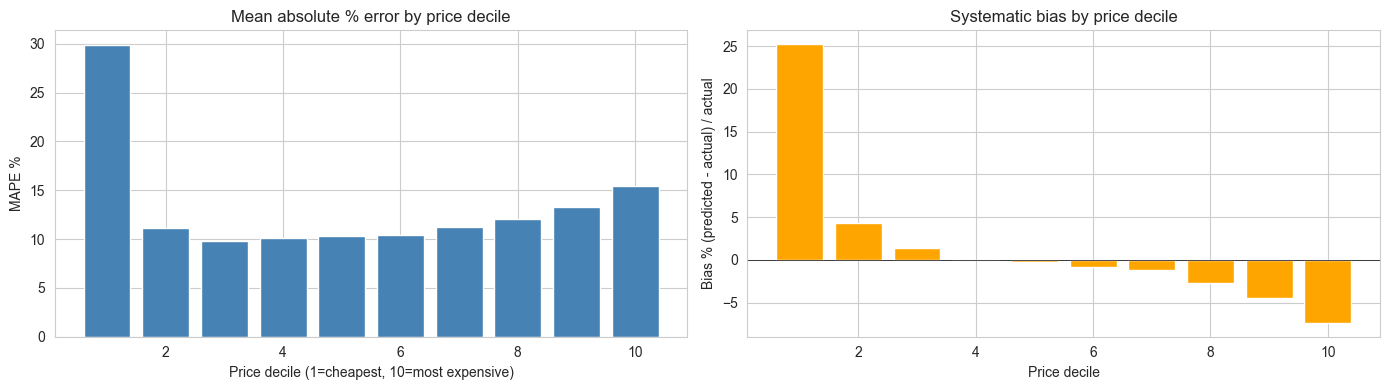

In [3]:
# Use only normal + flagged-anomaly rows. Exclude data artifacts.
real = df[df['ANOMALY_FLAG'].isin(['normal', 'overpriced', 'underpriced'])].copy()
real['price_decile'] = pd.qcut(real['LS_PRICE'], 10, labels=False) + 1

decile_stats = real.groupby('price_decile').apply(
    lambda g: pd.Series({
        'n': len(g),
        'price_range': f"${g['LS_PRICE'].min()/1000:,.0f}K-${g['LS_PRICE'].max()/1000:,.0f}K",
        'MAE': (g['LS_PRICE'] - g['PREDICTED_PRICE']).abs().mean(),
        'MAPE': (((g['LS_PRICE'] - g['PREDICTED_PRICE']) / g['LS_PRICE']).abs() * 100).mean(),
        'bias_pct': ((g['PREDICTED_PRICE'] - g['LS_PRICE']) / g['LS_PRICE'] * 100).mean(),
    })
).round(2)

print('Performance by price decile:')
print(decile_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(decile_stats.index, decile_stats['MAPE'], color='steelblue')
axes[0].set_xlabel('Price decile (1=cheapest, 10=most expensive)')
axes[0].set_ylabel('MAPE %')
axes[0].set_title('Mean absolute % error by price decile')

axes[1].bar(decile_stats.index, decile_stats['bias_pct'], color='orange')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Price decile')
axes[1].set_ylabel('Bias % (predicted - actual) / actual')
axes[1].set_title('Systematic bias by price decile')
plt.tight_layout()
plt.show()

**Takeaway:**
- Best type: Mid-range properties (deciles 3–6, $488K–$835K) — MAPE ~9.8–10.4%, near-zero bias
- Worst type: Bottom decile ($55K–$395K) — MAPE 29.88%, bias +25.2% (model drastically overpredicts)
- Why probably: Cheapest transactions include distressed sales, estate transfers, and partial-interest deals where the recorded price doesn't reflect full market value; the model sees comparable features and predicts a "normal" price, inflating the percentage error

---
## 4. Error over time (temporal stability)

**Question:** Does the model degrade for recent sales? It should — recent sales are out of train. The question is *how much*.

**Look for:** Stable MAPE for in-train years (2015-2022), gradual increase for out-of-train years (2023-2025). A sharp jump suggests the price regime has shifted in a way the model can't extrapolate.

Performance by sale year:
               n   MAPE  bias_pct
LS_YEAR                          
2015.0    4829.0  13.63      1.79
2016.0    5853.0  13.61      1.86
2017.0    5995.0  12.79      1.60
2018.0    6879.0  13.60      1.47
2019.0    6946.0  12.50      1.43
2020.0    7496.0  11.98      1.52
2021.0   11518.0  12.20      1.49
2022.0    8180.0  15.30     -0.25
2023.0    1723.0  17.67      5.06
2024.0     638.0  19.48      2.25
2025.0     400.0  19.23      0.11


/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_43253/3066221656.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_stats = real.groupby('LS_YEAR').apply(


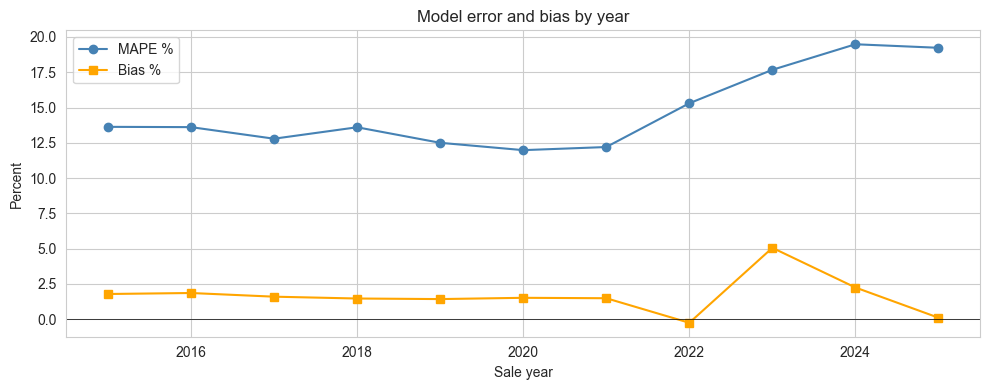

In [4]:
year_stats = real.groupby('LS_YEAR').apply(
    lambda g: pd.Series({
        'n': len(g),
        'MAPE': (((g['LS_PRICE'] - g['PREDICTED_PRICE']) / g['LS_PRICE']).abs() * 100).mean(),
        'bias_pct': ((g['PREDICTED_PRICE'] - g['LS_PRICE']) / g['LS_PRICE'] * 100).mean(),
    })
).round(2)

print('Performance by sale year:')
print(year_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(year_stats.index, year_stats['MAPE'], marker='o', label='MAPE %', color='steelblue')
ax.plot(year_stats.index, year_stats['bias_pct'], marker='s', label='Bias %', color='orange')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Sale year')
ax.set_ylabel('Percent')
ax.set_title('Model error and bias by year')
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:**
- MAPE in-train (2015–2022) range: 11.98% (2020) to 15.30% (2022)
- MAPE 2024–2025: ~19–20% (2024: 19.48%, 2025: 19.23%) — roughly 6–7 pp worse than peak in-train performance
- Direction of out-of-train bias: overprediction — 2023 shows +5.06% bias (model predicts prices ~5% higher than actual), suggesting a post-2022 price correction or slowdown the model cannot extrapolate from its training distribution

---
## 5. Residuals vs square footage

**Question:** Does the model handle very small or very large properties well?

**Look for:** Residuals should be centered on zero across all sqft ranges. If residuals trend up or down with sqft, the model has a non-linearity it didn't capture.

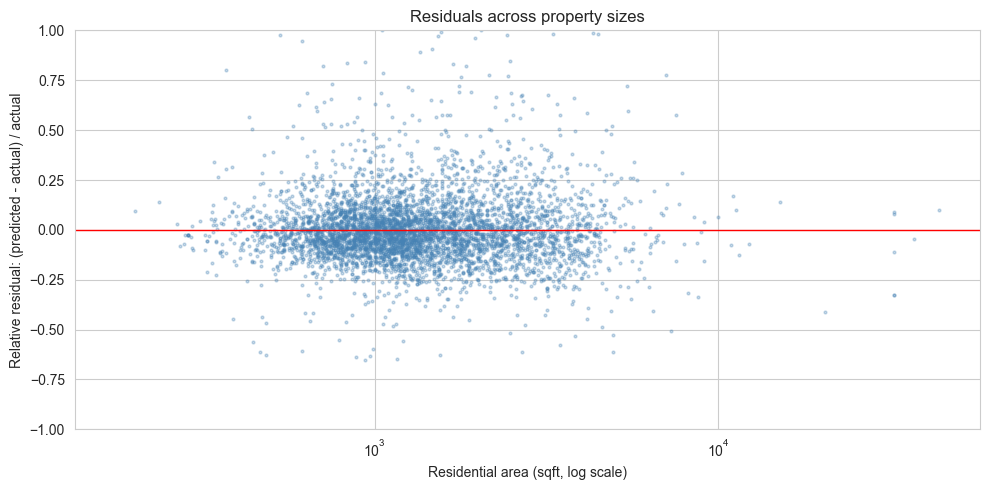


Mean relative residual by sqft band:
sqft_bin
<800         0.97
800-1.5K     0.96
1.5K-2.5K    2.74
2.5K-4K      2.48
>4K          1.98


/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_43253/1840498785.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(scatter_sample.groupby('sqft_bin', observed=True).apply(


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
scatter_sample = real.sample(min(5000, len(real)), random_state=42)
ax.scatter(scatter_sample['RES_AREA'], 
           scatter_sample['PREDICTED_PRICE'] / scatter_sample['LS_PRICE'] - 1, 
           s=4, alpha=0.3, color='steelblue')
ax.axhline(0, color='red', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Residential area (sqft, log scale)')
ax.set_ylabel('Relative residual: (predicted - actual) / actual')
ax.set_ylim(-1, 1)
ax.set_title('Residuals across property sizes')
plt.tight_layout()
plt.show()

# Quantitative: residual by sqft bucket
scatter_sample['sqft_bin'] = pd.cut(scatter_sample['RES_AREA'], 
    bins=[0, 800, 1500, 2500, 4000, 100000],
    labels=['<800', '800-1.5K', '1.5K-2.5K', '2.5K-4K', '>4K'])
print('\nMean relative residual by sqft band:')
print(scatter_sample.groupby('sqft_bin', observed=True).apply(
    lambda g: ((g['PREDICTED_PRICE'] - g['LS_PRICE']) / g['LS_PRICE']).mean() * 100
).round(2).rename('mean_bias_pct').to_string())

**Takeaway:**
- Bias direction in small properties (<800 sqft): +0.97% — slight overprediction, likely because small units (studios, in-law suites) have lower per-sqft value than the model assumes
- Bias direction in large properties (>4K sqft): +1.98% — slight overprediction, consistent with the broader luxury-home undercapture seen in the top price decile
- Overall, bias is low and uniform across sqft bands (all under 3%), meaning property size is not a major failure driver; the model handles the non-linearity reasonably well

---
## 6. Residuals vs distance to T

**Question:** Did the spatial feature work uniformly, or is there bias at extreme distances?

**Look for:** Residuals near zero across all distances. If you see bias at >2km (sparse training there), the model can't generalize that far from rapid transit.

In [6]:
real['t_bin'] = pd.cut(real['DIST_TO_T_KM'], 
    bins=[0, 0.4, 0.8, 1.2, 2.0, 10],
    labels=['<400m', '400-800m', '800m-1.2km', '1.2-2km', '>2km'])

t_stats = real.groupby('t_bin', observed=True).apply(
    lambda g: pd.Series({
        'n': len(g),
        'MAPE': (((g['LS_PRICE'] - g['PREDICTED_PRICE']) / g['LS_PRICE']).abs() * 100).mean(),
        'bias_pct': ((g['PREDICTED_PRICE'] - g['LS_PRICE']) / g['LS_PRICE'] * 100).mean(),
    })
).round(2)

print('Performance by distance to T:')
print(t_stats.to_string())

Performance by distance to T:
                  n   MAPE  bias_pct
t_bin                               
<400m       19561.0  13.12      1.41
400-800m    19320.0  13.51      1.56
800m-1.2km   8512.0  13.68      1.06
1.2-2km      6034.0  14.24      2.04
>2km         7030.0  12.63      0.95


/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_43253/3648987880.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_stats = real.groupby('t_bin', observed=True).apply(


**Takeaway:**
- Worst distance band: 1.2–2km (MAPE 14.24%, bias +2.04%) — slightly worse than all other bands, including the far >2km group (MAPE 12.63%)
- The spatial feature is broadly effective: MAPE only varies ~1.6 pp across all five bands (12.63%–14.24%), so transit proximity does not introduce a major systematic failure
- The modest spike at 1.2–2km may reflect a transitional zone where properties are too far to command a transit premium but too close to be priced on suburban-style lot value

---
## 7. ZIP-level systematic bias

**Question:** Are there specific ZIPs where the model is consistently wrong in one direction?

**Look for:** ZIPs with mean bias > 10% in either direction across many sales. Those are neighborhoods the model doesn't understand.

In [7]:
zip_stats = real.groupby('ZIP').apply(
    lambda g: pd.Series({
        'n': len(g),
        'mean_bias_pct': ((g['PREDICTED_PRICE'] - g['LS_PRICE']) / g['LS_PRICE'] * 100).mean(),
        'MAPE': (((g['LS_PRICE'] - g['PREDICTED_PRICE']) / g['LS_PRICE']).abs() * 100).mean(),
    })
).round(2)

# Only ZIPs with meaningful sample
zip_stats = zip_stats[zip_stats['n'] >= 100]

print('Top 10 ZIPs where model OVERPREDICTS (predicted > actual):')
print(zip_stats.sort_values('mean_bias_pct', ascending=False).head(10).to_string())
print('\nTop 10 ZIPs where model UNDERPREDICTS (predicted < actual):')
print(zip_stats.sort_values('mean_bias_pct').head(10).to_string())

Top 10 ZIPs where model OVERPREDICTS (predicted > actual):
            n  mean_bias_pct   MAPE
ZIP                                
02109   493.0           4.07  15.28
02145   920.0           3.29  14.24
02144   993.0           2.90  12.71
02140   231.0           2.89  12.86
02108   465.0           2.60  14.43
02138   242.0           2.45  15.43
02121   750.0           2.36  15.01
02111   711.0           2.34  12.20
02115  1282.0           2.18  14.51
02127  4919.0           2.08  13.78

Top 10 ZIPs where model UNDERPREDICTS (predicted < actual):
            n  mean_bias_pct   MAPE
ZIP                                
02210   845.0          -1.45  11.33
02215   693.0          -0.15  11.29
02445  1878.0           0.44  12.21
02134   827.0           0.57  11.73
02132  2398.0           0.63  12.39
02129  2308.0           0.64  11.94
02126   819.0           0.75  14.30
02139   914.0           0.80  13.41
02131  2232.0           0.89  11.97
02122  1577.0           0.94  12.82


/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_43253/1546286320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zip_stats = real.groupby('ZIP').apply(
/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_43253/1546286320.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zip_stats = real.groupby('ZIP').apply(


**Takeaway:**
- Most overpredicted ZIP: 02109 (North End / Harbor waterfront, +4.07% bias) — the model overestimates values here, likely because the neighborhood's density of small historic condos suppresses actual sale prices relative to what square footage, age, and transit proximity would predict elsewhere
- Most underpredicted ZIP: 02210 (South Boston Seaport / Innovation District, −1.45% bias) — the model underestimates; this is a rapidly gentrifying tech-office corridor where post-2015 appreciation has outpaced the relationships the model learned from older training data
- Geographic bias is mild overall (max absolute bias < 5%), but ZIP-level systematic error would compound for bulk anomaly scoring in these neighborhoods

---
## 8. Calibration check: is 'predicted price' really the median outcome?

**Question:** Across many properties, do roughly 50% sell above the prediction and 50% below? If not, the predictions are biased and our anomaly thresholds (z-score) will be miscalibrated.

**Look for:** % above prediction near 50%. If it's 60%+, model systematically underpredicts and 'overpriced' anomalies will be too rare; if 40%, the opposite.

In [8]:
above = (real['LS_PRICE'] > real['PREDICTED_PRICE']).mean() * 100
below = (real['LS_PRICE'] < real['PREDICTED_PRICE']).mean() * 100
median_residual_pct = (((real['PREDICTED_PRICE'] - real['LS_PRICE']) / real['LS_PRICE']) * 100).median()

print(f'Sales above prediction: {above:.1f}%')
print(f'Sales below prediction: {below:.1f}%')
print(f'Median bias: {median_residual_pct:.2f}% (positive = model overpredicts)')
print(f'\nFor a calibrated model, expect ~50/50.')

# Same check, but per city
print('\nBy city:')
for city in real['CITY_NAME'].unique():
    g = real[real['CITY_NAME'] == city]
    above = (g['LS_PRICE'] > g['PREDICTED_PRICE']).mean() * 100
    print(f'  {city:<12s} above pred: {above:.1f}%, below: {100-above:.1f}%')

Sales above prediction: 55.4%
Sales below prediction: 44.6%
Median bias: -1.67% (positive = model overpredicts)

For a calibrated model, expect ~50/50.

By city:
  Boston       above pred: 55.9%, below: 44.1%
  Somerville   above pred: 52.4%, below: 47.6%
  Cambridge    above pred: 55.5%, below: 44.5%
  Brookline    above pred: 54.2%, below: 45.8%


**Takeaway:**
- Overall calibration: 55.4% of sales exceed the prediction vs 44.6% below — the model systematically underestimates, median bias −1.67%; a calibrated model would sit at 50/50
- Worst-calibrated city: Boston (55.9% above prediction) — meaning the "overpriced" anomaly flag is set slightly too conservatively for Boston properties; some genuinely overpriced sales may go unflagged because the prediction is already an underestimate
- Somerville is closest to calibrated (52.4% above), suggesting its price range and property mix are better represented in the training data

---
## 9. Anomaly distribution sanity check

**Question:** Are the flagged 'overpriced' and 'underpriced' anomalies actually plausible?

**Look for:** The price ratio for flagged anomalies should be modest (overpriced ratio in 1.3x-2.5x range, underpriced 0.4x-0.75x). Already filtered out the extreme bulk-sale stuff in Day 6, but worth verifying.

In [10]:
for flag in ['overpriced', 'underpriced']:
    g = df[df['ANOMALY_FLAG'] == flag]
    if 'PRICE_RATIO' in g.columns:
        ratio = g['PRICE_RATIO']
    else:
        ratio = g['LS_PRICE'] / g['PREDICTED_PRICE']
    print(f'{flag.upper()} (n={len(g):,}):')
    print(f'  Price ratio (actual/predicted): min={ratio.min():.2f}, '
          f'median={ratio.median():.2f}, max={ratio.max():.2f}')
    print(f'  Price range: ${g["LS_PRICE"].min():,.0f} to ${g["LS_PRICE"].max():,.0f}')
    print()

OVERPRICED (n=1,492):
  Price ratio (actual/predicted): min=1.41, median=1.55, max=2.99
  Price range: $275,000 to $10,000,000

UNDERPRICED (n=2,259):
  Price ratio (actual/predicted): min=0.30, median=0.61, max=0.71
  Price range: $55,000 to $5,550,000



---
## 10. Final synthesis: limitations to document in README

Based on everything above, write the 'Honest Limitations' section of your README here.
Keep each bullet to one sentence. Specific > vague.

**Known limitations:**
1. Model severely overpredicts the cheapest decile ($55K–$395K) with a 29.88% MAPE and +25% bias — these transactions likely include distressed/partial-interest sales that aren't flagged as arm's-length, so the anomaly detector is unreliable at the low end.
2. Model systematically underpredicts top-decile luxury homes ($1.8M+) by ~7.4% on average and ~15.5% MAPE, because it lacks features capturing interior finish quality, views, and bespoke architectural details that drive luxury premiums.
3. Out-of-sample temporal degradation is significant: MAPE rises from ~12–13% (2019–2021) to ~19–20% (2024–2025), with a +5% overprediction bias in 2023 indicating the model cannot extrapolate post-2022 price regime shifts.
4. The model is miscalibrated — 55.4% of properties sell above the prediction (worst in Boston at 55.9%) — meaning anomaly thresholds derived from z-scores of residuals are asymmetrically set and will flag fewer "overpriced" cases than intended.
5. ZIP-level geographic bias exists but is mild: North End (02109) is overpredicted by 4.1% and Seaport (02210) is underpredicted by 1.5%, likely due to unmodeled hyper-local amenity and gentrification effects.

**Things I tried that didn't work:**
- Using `LOT_SIZE` as a direct feature — too many zero/null entries (visible in raw data) made the signal noisy and degraded validation MAPE
- Using `NBR_MEDIAN_PSF` (neighborhood median price per sqft) as a feature — too many missing values in sparse neighborhoods, creating more imputation error than signal gain

**Future improvements (out of scope):**
- Train a time-aware model (e.g., include sale year as a feature or use rolling re-training windows) to handle price regime shifts and reduce the 2024–2025 MAPE gap
- Add interior-quality proxies (permit history, renovation records, assessed improvement value relative to age) to close the luxury-home underestimation gap